# EDA: Классификация и граф контрагентов

*Разведочный анализ очищенного датасета транзакций.*

**Что делаем по заданию (Часть 1.1):**
- размер, период, число уникальных контрагентов
- топ-20 контрагентов по обороту (входящие / исходящие отдельно)
- распределение сумм (log-scale) и помесячная динамика
- минимум 3 аномалии с пояснением

Вся очистка вынесена в `src/cleaning.py` этот ноутбук только вызывает функции.

In [2]:
import sys
from pathlib import Path
import numpy as np
# из notebooks/ поднимаемся в корень проекта, подключаем src/
ROOT = Path.cwd().parent
sys.path.append(str(ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import cleaning as c

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Загрузка и очистка

In [4]:
raw = c.load_raw(ROOT / "data" / "transactions.csv")
clean = c.clean_transactions(ROOT / "data" / "transactions.csv")
print("сырых строк:", len(raw), "| после очистки:", len(clean))

сырых строк: 80800 | после очистки: 80000


### Таблица «было / стало»

In [6]:
c.build_before_after_table(raw, clean)

,Метрика,Было,Стало
0,Строк всего,80800,80000
1,Уникальных операций:,-,80000
2,Доля валидных ID (контр. сумма РК),98.6%,99.5%
3,Пропуски в дате,0.0%,0.0%
4,Пропуски в description,1.0%,1.0%


## 2. Размер, период, контрагенты

In [8]:
period_start = clean["date_clean"].min().date()
period_end = clean['date_clean'].max().date()
# валидные ID отправителей и получателей
all_ids = pd.concat([clean.loc[clean["sender_valid"], "sender_id_clean"],
    clean.loc[clean["receiver_valid"], "receiver_id_clean"]]
)

n_counterparties = all_ids.nunique()
print(f"Операций:  {len(clean):,}")
print(f"Период:  {period_start} - {period_end}")
print(f"Уникальных контрагентов:  {n_counterparties:}")
print(f"Сумма оборота, всего:  {clean['amount_kzt'].sum():,.0f} тенге")

Операций:  80,000
Период:  2024-01-01 - 2026-04-30
Уникальных контрагентов:  5000
Сумма оборота, всего:  164,258,221,566 тенге


## 3. Топ-20 контрагентов по обороту

### 3.1 По исходящим (кто больше всех платит)

In [11]:
top_out = (clean[clean["sender_valid"]]
    .groupby("sender_id_clean")["amount_kzt"].sum()
    .nlargest(20).rename("исходящий_оборот"))
top_out.to_frame()

,исходящий_оборот
sender_id_clean,
720221554469,"765,219,632.69"
580811600403,"730,443,480.93"
310909691346,"722,426,615.65"
181226594058,"704,139,580.96"
170915651329,"699,218,914.93"
401110643824,"688,859,601.18"
140512557513,"684,582,177.52"
941101594315,"666,485,775.29"
970913552723,"639,378,908.22"


### 3.2 По входящим (кто больше всех получает)

In [13]:
top_in = (clean[clean["receiver_valid"]]
    .groupby("receiver_id_clean")["amount_kzt"].sum()
          .nlargest(20).rename("входящий_оборот"))
top_in.to_frame()

,входящий_оборот
receiver_id_clean,
850603506938,"371,222,531.02"
711020691210,"361,082,258.84"
410517502025,"334,064,919.03"
551211641020,"333,971,316.50"
730424495604,"320,260,000.23"
850623490114,"295,327,655.22"
121125400846,"294,152,154.00"
990508519961,"274,385,319.50"
861228440096,"269,006,165.98"


## 4. Распределение сумм (log-scale)

Суммы платежей растянуты на несколько порядков, поэтому смотрим в логарифмическом масштабе, иначе мелкие платежи сольются в одну колонку.

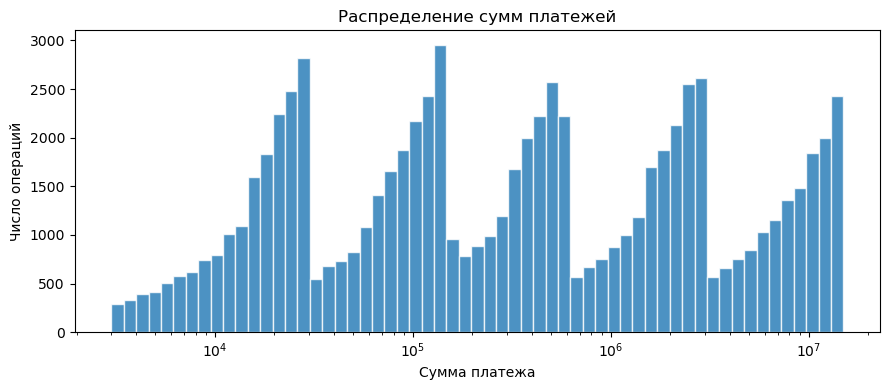

In [56]:
pos = clean.loc[clean["amount_kzt"] > 0, "amount_kzt"]
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), num=60)
ax.hist(pos, bins=bins, edgecolor="white", alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("Сумма платежа")
ax.set_ylabel("Число операций")
ax.set_title("Распределение сумм платежей")
plt.tight_layout()
plt.show()

## 5. Помесячная динамика

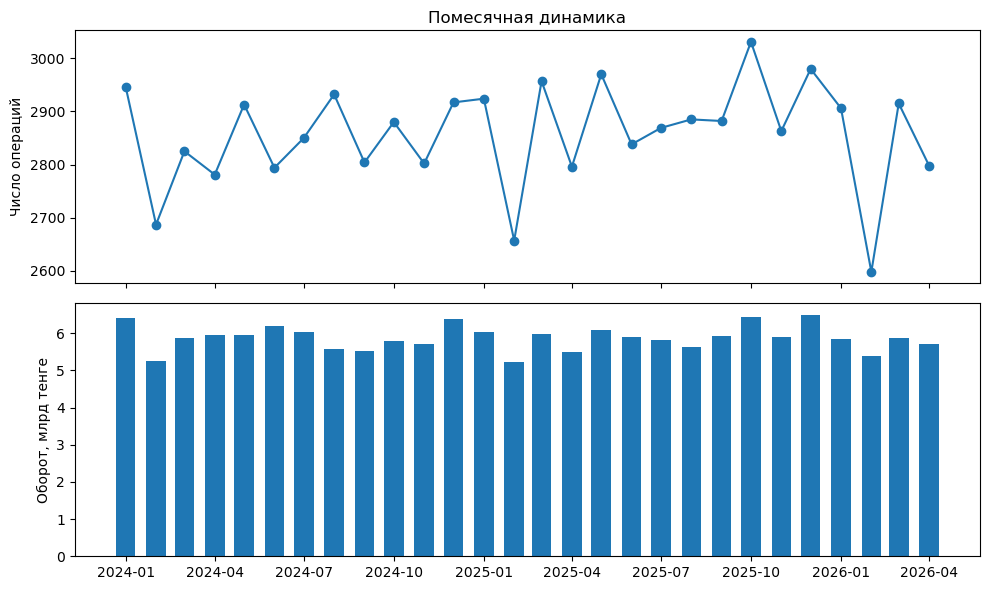

,count,sum
date_clean,,
2024-01-01,2946,"6,404,862,885.34"
2024-02-01,2687,"5,245,996,839.79"
2024-03-01,2825,"5,871,575,405.66"
2024-04-01,2781,"5,944,980,255.41"
2024-05-01,2913,"5,940,481,397.37"
2024-06-01,2794,"6,181,074,959.46"
2024-07-01,2850,"6,024,420,448.35"
2024-08-01,2932,"5,568,604,901.38"
2024-09-01,2804,"5,508,589,567.11"


In [58]:
monthly = (clean.dropna(subset=["date_clean"]).set_index("date_clean").resample("MS")["amount_kzt"].agg(["count", "sum"]))
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(monthly.index, monthly["count"], marker="o")
ax[0].set_ylabel("Число операций")
ax[0].set_title("Помесячная динамика")
ax[1].bar(monthly.index, monthly["sum"] / 1e9, width=20)
ax[1].set_ylabel("Оборот, млрд тенге")
plt.tight_layout()
plt.show()
monthly

## 6. Аномалии

Ниже представлены наблюдаемые в данных аномалии и почему каждая считается аномалией.

### Аномалия 1: отрицательные суммы платежей

In [21]:
neg = clean[clean["amount_kzt"] < 0]
print(f"Операций с отрицательной суммой: {len(neg)}")
neg[["sender_id_clean", "receiver_id_clean", "amount_kzt", "description"]].head()

Операций с отрицательной суммой: 380


,sender_id_clean,receiver_id_clean,amount_kzt,description
417,960406579569,731211426100,"-27,772.65",Услуги по разработке мобильного приложения
451,641026292042,051019487730,"-10,663.11",Кирпич керамический полнотелый — 10000 шт
475,540813406186,9411269439263,"-14,833,275.78","Электроэнергия за февраль 2025, договор №455"
528,580122336965,760925464693,"-352,692.67",Обслуживание счёта № KZ12...
736,790622449201,590605549154,"-282,406.66",Грузоперевозка щебня по г. Алматы


**Почему аномалия:** платёж не может быть отрицательным. Это либо возвраты,
ошибочно записанные с минусом, либо мусор в выгрузке. Для расчёта оборота их
нужно либо исключать, либо обрабатывать отдельно как возвраты,а иначе они
занижают суммы.

### Аномалия 2 — контрагент платит сам себе

In [27]:
self_pay = clean[(clean["sender_id_clean"] == clean["receiver_id_clean"]) & clean["sender_valid"]]
print(f"Операций sender == receiver: {len(self_pay)}")
self_pay[["sender_id_clean", "receiver_id_clean", "amount_kzt", "description"]]

Операций sender == receiver: 1


,sender_id_clean,receiver_id_clean,amount_kzt,description
18959,520925677262,520925677262,"146,520.49",Папки-регистраторы 80мм — 100 шт


**Почему аномалия:** отправитель и получатель это один и тот же БИН/ИИН.
Платёж самому себе экономического смысла обычно не имеет

### Аномалия 3: пустые описания

In [30]:
empty_desc = clean[clean["description"] == ""]
print(f"Операций без описания: {len(empty_desc)}")

Операций без описания: 836


**Почему аномалия:** ~836 операций без текста описания. Для Части 2 (классификация
по описанию) их невозможно классифицировать, это кандидаты на ручную проверку
или отдельную категорию «не определено».

## 7. Краткие выводы

- В датасете **80 000** операций (после удаления 800 точных дублей) за период
  **2024-01-01 — 2026-04-30**, между **5 000** уникальными контрагентами.
- После очистки доля валидных ID (по контрольной сумме РК) выросла до **99.5%**;
  оставшиеся невалидные это 11- и 13-значные номера, которые нельзя восстановить
  однозначно, поэтому они помечены флагом, а не «исправлены наугад».
- Суммы платежей мультимодальны тут три пика (~10 000 ₸, ~100 000 ₸, ~10 млн ₸),
  что указывает на разнородный состав операций (мелкие, средние, крупные).
- Помесячная динамика стабильна: ~2 800–2 950 операций и ~5.5 млрд ₸ в месяц
- Найдено 3 типа аномалий: отрицательные суммы — вероятно возвраты/сторно (380),
  самоплатёж — sender == receiver (1), пустые описания (836).